# Ma’lumotlarni tahlil qilishning qisqa yo‘li (EDA)

EDA - bu ma’lumotlar to‘plamlarini tahlil qilish va vizuallashtirishga qaratilgan yondashuv bo‘lib, ko‘pincha statistik grafikalar va boshqa ma’lumotlarni vizualizatsiya usullari yordamida ularning asosiy xususiyatlarini umumlashtiradi. EDAning asosiy maqsadi ma’lumotlardagi qonuniyatlar, munosabatlar, anomaliyalar va tendentsiyalarni aniqlash orqali keyingi tahlil yoki qaror qabul qilish jarayonlarini yo‘naltiruvchi tushunchalarni taqdim etishdir.

Ma’lumotlarni tahlil qilish turlari

-- EDAning uch asosiy turi mavjud:

* Bir o‘zgaruvchili
* Ikki o‘zgaruvchili
* Ko‘p o‘zgaruvchili

## **1-qadam: Ma’lumotlarni anglash**

* Ma’lumotlar to‘plami bilan tanishib chiqing, jumladan yozuvlar soni, ustunlar va ma’lumot turlarini o‘rganing.
* Maqsadli o‘zgaruvchini aniqlang (agar mavjud bo‘lsa) va uning ahamiyatini tushunib oling.

### Importing Libraries

In [1]:
import pandas as pd

In [2]:
data = pd.read_csv("../../data/product_data.csv")

## 1. Ma’lumotlar hajmi:

Savol: Ma’lumotlar qancha hajmga ega?

Yondashuv: Ma’lumotlar to‘plamining o‘lchamini tekshiring.

-- ’shape’ funksiyasi qatorlar va ustunlar sonini qaytaradi.

In [3]:
data.shape

(60, 10)

## 2. Ma’lumotlarni ko‘zdan kechirish:

Savol: Ma’lumotlar qanday ko‘rinishga ega?

Yondashuv: head() yoki sample() funksiyalaridan foydalanib ma’lumotlar to‘plamining dastlabki bir necha qatorini ko‘rib chiqing.

-- head() funksiyasi ma’lumotlar to‘plamining birinchi bir necha qatorini ko‘rsatadi.

-- sample() funksiyasi ma’lumotlar to‘plamidan tasodifiy tanlangan qatorlarni ko‘rsatadi.

In [4]:
data.head(5)

,ProductID,ProductName,Category,Price,CustomerRating,PromotionType,CustomerAge,ShippingTime,CustomerSatisfaction,ShippingDate
0,1,Smartphone X,Electronics,500,4.2,Discount,Young,2,4,02/15/2022
1,2,Fashion Jacket,Clothing,80,4.5,Bundle Offer,Adult,3,5,08/20/2021
2,3,Kitchen Blender,Home & Kitchen,120,3.8,NaN,Senior,4,3,05/10/2022
3,4,Running Shoes,Sports,60,4.0,Discount,Young,2,4,11/03/2022
4,5,LED TV,Electronics,700,4.3,NaN,Adult,3,4,06/27/2021


In [6]:
data.sample(5)

,ProductID,ProductName,Category,Price,CustomerRating,PromotionType,CustomerAge,ShippingTime,CustomerSatisfaction,ShippingDate
10,11,Laptop Bag,Electronics,30,4.0,NaN,Young,2,3,08/07/2022
2,3,Kitchen Blender,Home & Kitchen,120,3.8,NaN,Senior,4,3,05/10/2022
30,201,Wireless Mouse,Electronics,15,4.2,NaN,Young,2,4,02/15/2022
31,202,Comforter Set,Home & Kitchen,80,4.5,Bundle Offer,Adult,3,5,08/20/2021
49,220,Smart Thermostat,Smart Home,90,4.1,Discount,Adult,3,4,12/30/2022


## 3. Ma’lumot turlari:

Savol: Har bir ustunda qanday turdagi ma’lumotlar saqlanadi?

Yondashuv: dtypes yoki info() funksiyalaridan foydalanib, har bir ustunning ma’lumot turlarini tekshiring.

-- info() funksiyasi ma’lumotlar to‘plami haqidagi ma’lumotlarni, shu jumladan xotiradan foydalanish ko‘rsatkichlarini taqdim etadi.

-- dtypes xususiyati har bir ustunning ma’lumot turlarini qaytaradi.

In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   ProductID             60 non-null     int64  
 1   ProductName           60 non-null     object 
 2   Category              60 non-null     object 
 3   Price                 60 non-null     int64  
 4   CustomerRating        60 non-null     float64
 5   PromotionType         25 non-null     object 
 6   CustomerAge           60 non-null     object 
 7   ShippingTime          60 non-null     int64  
 8   CustomerSatisfaction  60 non-null     int64  
 9   ShippingDate          60 non-null     object 
dtypes: float64(1), int64(4), object(5)
memory usage: 4.8+ KB


In [8]:
data.dtypes

ProductID                 int64
ProductName              object
Category                 object
Price                     int64
CustomerRating          float64
PromotionType            object
CustomerAge              object
ShippingTime              int64
CustomerSatisfaction      int64
ShippingDate             object
dtype: object

## 4. Yo‘q qiymatlar:

Savol: Ma’lumotlarda nol yoki yo‘q qiymatlar mavjudmi?

Yondashuv: isnull() yoki isna() funksiyalaridan foydalanib, yo‘q qiymatlarning mavjudligini tekshiring.


-- ’isnull().sum()’ yoki ’isna().sum()’ har bir ustundagi yo‘q qiymatlarning umumiy sonini ko‘rsatadi.


-- ’isnull().mean() * 100’ yo‘q qiymatlarning foizini beradi.

In [9]:
data.isna().sum()

ProductID                0
ProductName              0
Category                 0
Price                    0
CustomerRating           0
PromotionType           35
CustomerAge              0
ShippingTime             0
CustomerSatisfaction     0
ShippingDate             0
dtype: int64

In [10]:
data.isnull().mean() * 100

ProductID                0.000000
ProductName              0.000000
Category                 0.000000
Price                    0.000000
CustomerRating           0.000000
PromotionType           58.333333
CustomerAge              0.000000
ShippingTime             0.000000
CustomerSatisfaction     0.000000
ShippingDate             0.000000
dtype: float64

## 5. Statistik tahlil:

Savol: Ma’lumotlar statistik jihatdan qanday taqsimlangan?

Yondashuv: describe() funksiyasi yordamida statistik ko‘rsatkichlarni olish.

- describe() funksiyasi raqamli ustunlar uchun statistik ko‘rsatkichlarni taqdim etadi.

In [11]:
data.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
ProductID,60.0,115.500000,101.220936,1.0,15.75,115.5,215.25,230.0
Price,60.0,69.383333,110.925550,8.0,23.75,40.0,70.00,700.0
CustomerRating,60.0,4.106667,0.277926,3.5,3.90,4.1,4.30,4.6
ShippingTime,60.0,2.966667,0.822701,2.0,2.00,3.0,4.00,4.0
CustomerSatisfaction,60.0,3.600000,0.994902,2.0,3.00,4.0,4.00,5.0


-- ’Markaziy tendensiya’: Bu atama ma’lumotlarning markaziy holati yoki o‘rta qismida joylashgan qiymatlarni ifodalaydi.

Markaziy tendensiyaning uchta umumiy baholanadigan ko‘rsatkichi o‘rtacha, mediana va modadir.

-- O‘rtacha qiymat ma’lumotlardagi barcha qiymatlarning o‘rtachasidir.

-- Moda esa eng ko‘p marta uchraydigan qiymatdir.

-- Mediana o‘zining chap va o‘ng tomonlarida teng miqdordagi kuzatuvlarga ega bo‘lgan o‘rta qiymatdir.

In [12]:
data["CustomerSatisfaction"].skew()

np.float64(-0.28629649843102617)

## 6. Takroriy ma’lumotlar:

Savol: Takrorlanuvchi qiymatlar mavjudmi?

Yondashuv: duplicated() funksiyasi yordamida takroriy qiymatlarni aniqlash va olib tashlash.

-- duplicated().sum() takroriy qatorlar sonini hisoblaydi.

-- drop_duplicates() takroriy qatorlarni olib tashlaydi.

In [13]:
print("Total duplicate values are '", data.duplicated().sum(), "'.")

Total duplicate values are ' 0 '.


## 7. Korrelyatsion tahlil:

Savol: Turli ustunlar o‘zaro qanday bog‘liq?

Yondashuv: Korrelyatsiya matritsasini o‘rganing va kerak bo‘lsa, uni vizuallashtiring.

-- ’corr()’ funksiyasi korrelyatsiya matritsasini hisoblab beradi.

-- ’heatmap()’ funksiyasi korrelyatsiya matritsasini vizual ko‘rinishda ifodalaydi.

In [15]:
data.corr()

ValueError: could not convert string to float: 'Smartphone X'

## 8. Xilma-xillikni o‘rganish:

Savol: Ma’lum bir ustunda nechta noyob qiymat mavjud?
Yondashuv: Muayyan ustundagi noyob qiymatlar sonini aniqlash uchun nunique() metodidan foydalaning.

-- ’nunique()’ metodi har bir ustun uchun noyob qiymatlar sonini qaytaradi.

In [16]:
data["ProductName"].nunique()

# Eslatma: Kategoriya ustunidagi xilma-xillik va turli-tumanlikni tushunib oling. 
# Noyob qiymatlarning ko‘pligi kategoriyalar orasidagi rang-baranglikning yuqori darajasini ko‘rsatishi mumkin.

60

# **2-bosqich: Bir o‘zgaruvchili grafik tahlil**

* Bu ma’lumotlar to‘plamidagi bitta o‘zgaruvchini o‘rganish va tahlil qilishni anglatadi.
* U qisqacha statistik ma’lumotlarni tayyorlash, vizual tasvirlarni (masalan, gistogrammalar, quti diagrammalari) yaratish hamda ushbu aniq o‘zgaruvchining taqsimoti va xususiyatlarini tushunishni o‘z ichiga oladi.

### 1. Categorical Data

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

## a. Hisoblovchi grafik

-- Maqsad: Kategorik o‘zgaruvchidagi har bir toifaning takrorlanishini sanash.

-- Qo‘llanilishi: ’sns.countplot(x=’toifa_ustuni’, data=ma’lumotlar)’

In [18]:
data["Category"].nunique()

12

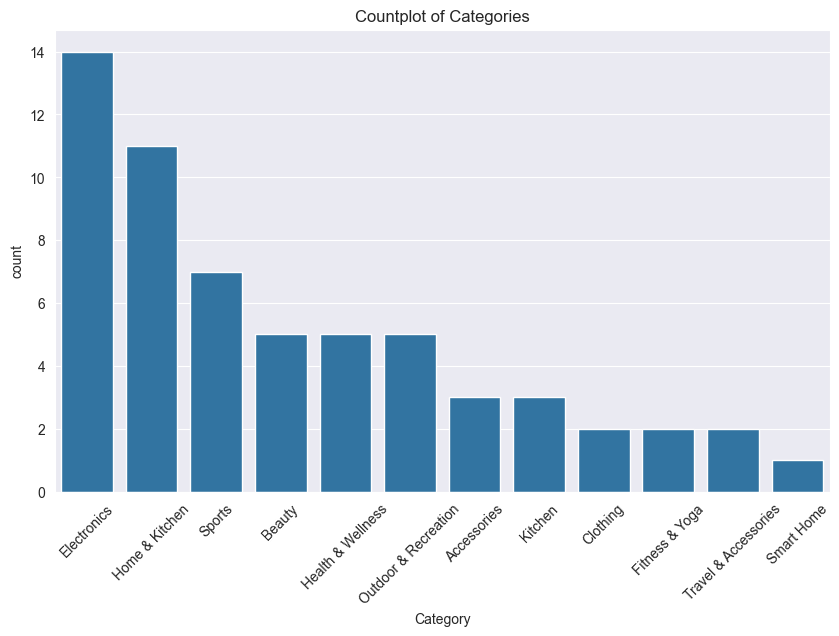

In [19]:
# Using a countplot to understand the "Category"
plt.figure(figsize=(10, 6))
sns.countplot(data=data, x="Category", order=data["Category"].value_counts().index)
plt.xticks(rotation=45)
plt.title("Countplot of Categories")
plt.show()

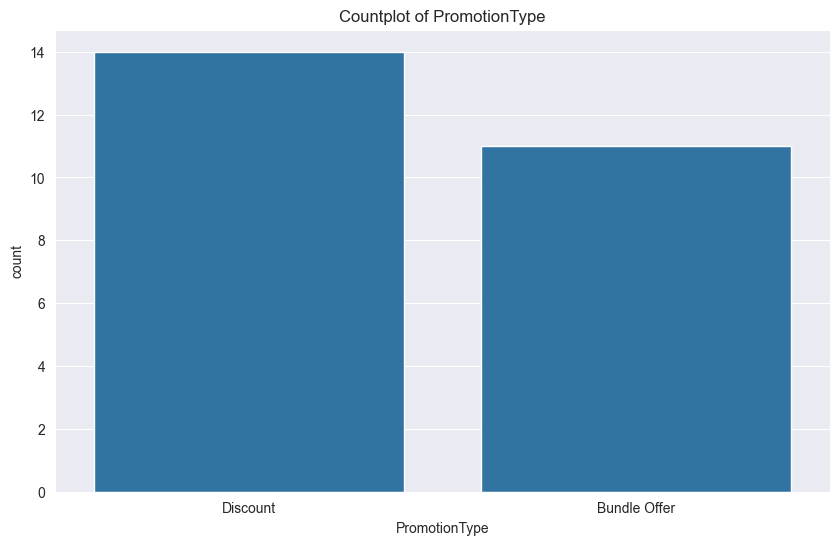

In [20]:
# Using a countplot to understand the "PromotionType"
plt.figure(figsize=(10, 6))
sns.countplot(data=data, x="PromotionType", order=data["PromotionType"].value_counts().index)
plt.title("Countplot of PromotionType")
plt.show()

*Izoh: Bu, kategorik o‘zgaruvchining har bir toifasidagi kuzatishlar sonini ustunlar orqali ko‘rsatish va bitta o‘zgaruvchi ichidagi turli toifalar chastotasini oson taqqoslash uchun qo‘llaniladi.*

## b. Doiraviy diagramma

-- Maqsad: Kategorik o‘zgaruvchidagi har bir toifaning ulushini ko‘rsatish.

-- Qo‘llanilishi: ’plt.pie(data[’category_column’].value_counts(), labels=data[’category_column’].value_counts().index)’

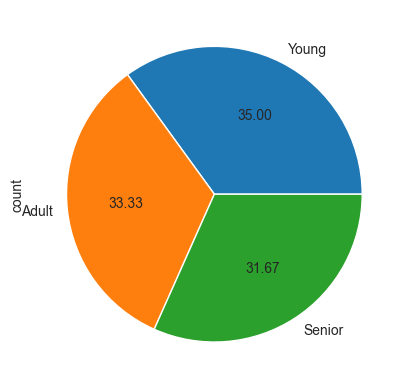

In [21]:
# Using a piechart to understand the "CustomerAge"
data["CustomerAge"].value_counts().plot(kind="pie", autopct = "%.2f")
plt.show()

*Izoh: Doiraviy diagramma umumiy ma’lumotlar ichida har bir toifaga tegishli qismning foizini ko‘rsatish orqali, alohida toifalarning jamiga qo‘shgan hissasini vizual tarzda tasvirlaydi.*

### 2. Raqamli ma’lumotlar

## a. Gistogramma

Gistogrammalar - ustunli diagramma bo‘lib, unda har bir ustun qiymatlar oralig‘i uchun holatlarning chastotasini (sonini) yoki ulushini (soni/umumiy son) ifodalaydi.

-- Maqsad: Bitta sonli o‘zgaruvchining taqsimotini ko‘rsatish.

-- Qo‘llanilishi: ’plt.hist(data[’column’])’

(array([ 2.,  4.,  6.,  5., 10.,  6.,  9.,  5.,  4.,  9.]),
 array([3.5 , 3.61, 3.72, 3.83, 3.94, 4.05, 4.16, 4.27, 4.38, 4.49, 4.6 ]),
 <BarContainer object of 10 artists>)

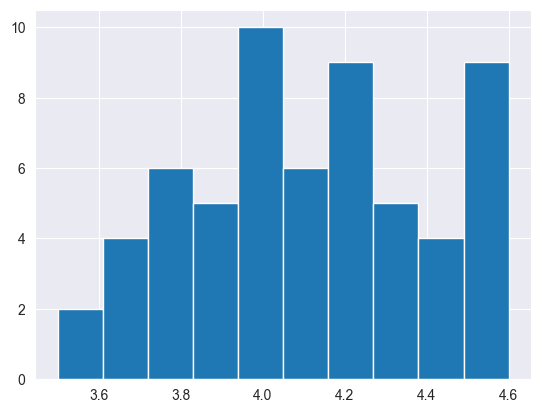

In [22]:
# Using a histplot to understand the "CustomerRating"
plt.hist(data["CustomerRating"])

*Eslatma: Ma’lumotlar taqsimotining umumiy shaklini tushunish, shu jumladan qiymatlarning nomutanosibligini, cho‘qqilarini yoki bo‘shliqlarini aniqlash.*

## b. Distplot

-- Maqsad: Sonli ustunning taqsimotini vizualizatsiya qilish.

-- Qo‘llanilishi: ’sns.distplot(data[’NumericalColumn’])’

In [36]:
import warnings


/var/folders/8q/ww9wlcg946l4mbz6q4n9yylc0000gn/T/ipykernel_37824/2291628050.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data["ShippingTime"])


<Axes: xlabel='ShippingTime', ylabel='Density'>

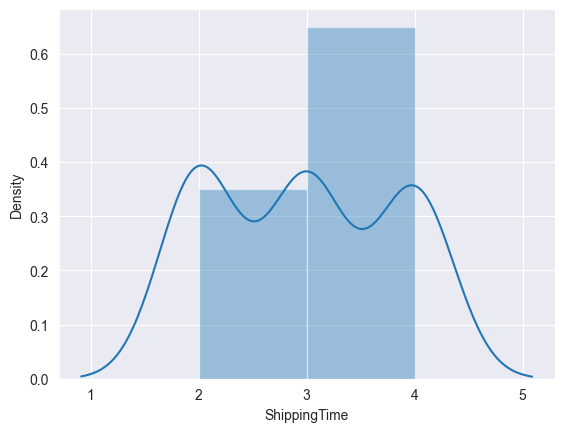

In [23]:
# Using a distplot to understand the "ShippingTime"
sns.distplot(data["ShippingTime"])

*Izoh: Bu taqsimot yoki zichlik shaklini tushunishga, chetki qiymatlarni aniqlashga va raqamli ma’lumotlarning umumiy qonuniyatini baholashga yordam beradi.*

## c. Quti diagrammasi (quti va mo‘ylov diagrammalari)

Quti diagrammalari minimum, birinchi kvartil, mediana, uchinchi kvartil va maksimum qiymatlardan iborat beshta sonli xulosani grafik tarzda tasvirlaydi.

-- Maqsad: Sonli ma’lumotlardagi umumiy statistikani ko‘rsatish va chetki qiymatlarni aniqlash.

-- Qo‘llanilishi: ’sns.boxplot(x=’ustun’, data=ma’lumotlar)’

<Axes: ylabel='CustomerRating'>

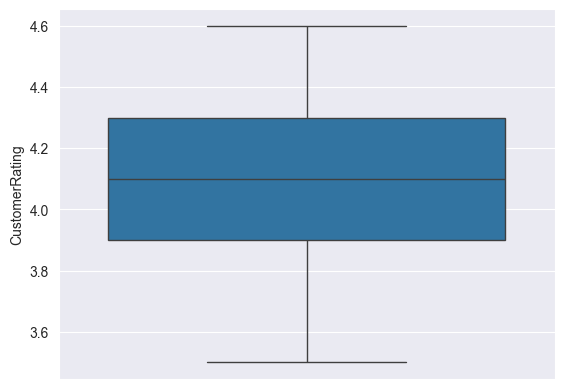

In [24]:
# Using a boxplot to understand the "CustomerRating"
sns.boxplot(data["CustomerRating"])

*Eslatma: Raqamli ma’lumotlarning turli toifalar bo‘yicha taqsimlanishi va markaziy tendensiyasini tasavvur qiling. Bu orqali alohida toifali guruhlar ichidagi o‘zgarishlarni, chetki qiymatlarni va raqamli ko‘rsatkichlarning umumiy tarqalishini aniqlashga e’tibor qarating.*

# **3-bosqich: Ikki o‘lchovli/ko‘p o‘lchovli grafik tahlil**


Ikki o‘lchovli grafik tahlil ikki o‘zgaruvchi orasidagi munosabatni vizual tasvirlash orqali o‘rganishni o‘z ichiga oladi.

Ko‘p o‘lchovli tahlil ikki o‘lchovli tahlilning kengaytirilgan shakli bo‘lib, bir vaqtning o‘zida bir nechta o‘zgaruvchilar orasidagi o‘zaro bog‘liqlikni aniqlash uchun qo‘llaniladi.

Bu yerda biz uchta asosiy turni ko‘rib chiqamiz:

* Raqamli va raqamli
* Toifali va raqamli
* Toifali va toifali ma’lumotlar

In [25]:
tips_data = sns.load_dataset('tips')

In [26]:
tips_data.columns

Index(['total_bill', 'tip', 'sex', 'smoker', 'day', 'time', 'size'], dtype='object')

In [27]:
tips_data

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


## *I. (Raqamli - raqamli) ustunlarni vizuallashtirish*

## 1. Tarqoq diagramma

-- Maqsad: Ikki sonli o‘zgaruvchi orasidagi munosabatni o‘rganish.

-- Qo‘llanilishi: ’plt.scatter(data[’x_ustun’], data[’y_ustun’])’

In [28]:
# Using a scatterplot to check the correlation between "total_bill, "tip", "sex, "smoker and "sex"
sns.scatterplot(tips_data['total_bill'],tips_data['tip'],hue=tips_data['sex'],style=tips_data['smoker'],size=tips_data['size'])
xlabel='total_bill', 
ylabel='tip'

TypeError: scatterplot() takes from 0 to 1 positional arguments but 2 positional arguments (and 3 keyword-only arguments) were given

*Eslatma: Grafikdagi nuqtalar orasidagi qonuniyatlar, tendensiyalar yoki o‘zaro bog‘liqliklarni aniqlang va bu orqali o‘zgaruvchilar o‘rtasidagi munosabatlar haqida muhim ma’lumotlarni yoritib bering.*

## 2. Chiziqli diagramma

-- Maqsad: Ikki uzluksiz o‘zgaruvchi orasidagi munosabatni aks ettirish.

-- Qo‘llanilishi: ’sns.lineplot(x=’O‘zgaruvchi1’, y=’O‘zgaruvchi2’, data=ma’lumotlar)’

In [ ]:
# Using a lineplot to check the relation between "total_bill" and "size"
sns.lineplot(tips_data['total_bill'],tips_data['size'])


*Eslatma: Bu usul odatda vaqt qatori ma’lumotlari yoki ma’noli tartibga ega bo‘lgan boshqa turdagi ma’lumotlar uchun qo‘llaniladi. U orqali ma’lumotlardagi tendensiyalar, qonuniyatlar yoki o‘zgarishlarni kuzatish imkoniyati yaratiladi.*

## *II. Raqamli va toifali ustunlarni vizuallashtirish*

## 1. Ustunli diagramma

-- Maqsad: Kategorik o‘zgaruvchilarning taqsimotini vizuallashtirish.

-- Qo‘llanilishi: ’plt.bar(data[’category_column’].value_counts().index, data[’category_column’].value_counts())’

In [ ]:
data.columns

In [ ]:
# Using a barplot to check the correlation between "CustomerRating" and "CustomerSatisfaction"
sns.barplot(data["CustomerRating"], data["CustomerSatisfaction"])

*Note: Compare and highlight the differences in values between different categories using bars of varying lengths*

## 2. Toifalar bo‘yicha guruhlangan quti diagrammasi:

- Maqsad: Sonli o‘zgaruvchining turli toifalar bo‘yicha taqsimlanishini taqqoslash.

- Qo‘llanilishi: ’sns.boxplot(x=’toifa_ustuni’, y=’sonli_ustun’, data=ma’lumotlar)’

In [29]:
# Using a boxplot to check the corelation between "CustomerRating" and "ShippingTime                                                                               "
sns.boxplot(data["CustomerRating"], data["ShippingTime"])

TypeError: boxplot() takes from 0 to 1 positional arguments but 2 were given

*Note:  Identify variations, outliers, and the overall spread of numerical values within distinct categorical groups.*

## 3. Distplot

-- Maqsad: Sonli o‘zgaruvchilarning taqsimotlarini toifalar bo‘yicha taqqoslash.

-- Qo‘llanilishi: ’sns.distplot(data[’NumericalColumn’], hue=data[’CategoricalColumn’], kde=False)’

/var/folders/8q/ww9wlcg946l4mbz6q4n9yylc0000gn/T/ipykernel_37824/2372241205.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data[data["ShippingTime"] == 2]["CustomerRating"],hist=False, label="ShippingTime 2 days")
/var/folders/8q/ww9wlcg946l4mbz6q4n9yylc0000gn/T/ipykernel_37824/2372241205.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist

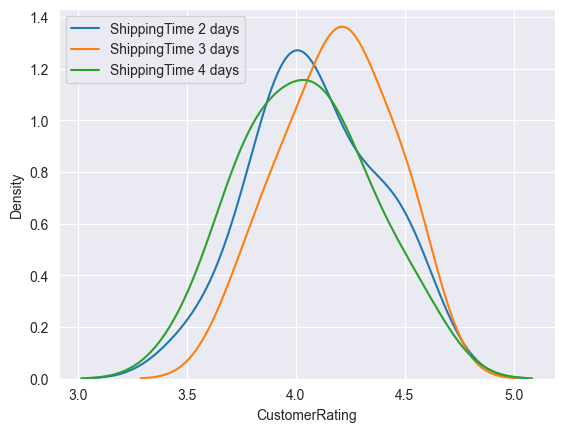

In [30]:
# Using a distplot to check the compare between "ShippingTime" and "CustomerRating"

sns.distplot(data[data["ShippingTime"] == 2]["CustomerRating"],hist=False, label="ShippingTime 2 days")
sns.distplot(data[data["ShippingTime"] == 3]["CustomerRating"],hist=False, label="ShippingTime 3 days")
sns.distplot(data[data["ShippingTime"] == 4]["CustomerRating"],hist=False, label="ShippingTime 4 days")
# Adding legend
plt.legend()
xlabel='CustomerRating', 
ylabel='Density'
# Display the plot
plt.show()

*Note: This variation helps in exploring how the distribution of numerical values varies among different groups or classes defined by a categorical variable.*

## *III. Visualizing (Categorical - Categorical) Columns*

## 1. Issiqlik xaritasi

- Maqsad: Sonli o‘zgaruvchilar orasidagi korrelyatsiya koeffitsiyentlarini ko‘rsatish.

- Qo‘llanilishi: ’sns.heatmap(data.corr(), annot=True)’

In [31]:
pd.crosstab(tips_data['sex'],tips_data['smoker'])	

smoker,Yes,No
sex,,
Male,60,97
Female,33,54


<Axes: xlabel='smoker', ylabel='sex'>

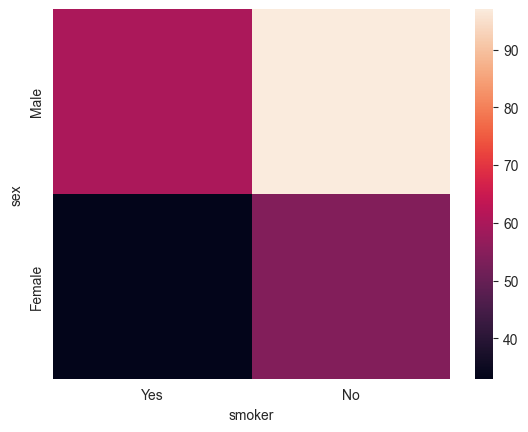

In [32]:
# Using a heat map to check the correlation between "sex" and "smoker"
sns.heatmap(pd.crosstab(tips_data['sex'],tips_data['smoker']))

*Note: It that shows the magnitude of the phenomenon as colour in two dimensions. The values of correlation can vary from -1 to 1 where -1 means strong negative and +1 means strong positive correlation.*

In [33]:
(tips_data.groupby('sex').mean()['size']*100)

/var/folders/8q/ww9wlcg946l4mbz6q4n9yylc0000gn/T/ipykernel_37824/493726207.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  (tips_data.groupby('sex').mean()['size']*100)


TypeError: category dtype does not support aggregation 'mean'

## 2. ClusterMap

Maqsad: Ma’lumotlar to‘plamidagi klasterlarni (ayniqsa ierarxik klasterlashni) vizualizatsiya qilish.

Qo‘llanilishi: ’sns.clusterplot(data)’

In [ ]:
# Using a cluster map to check the correlation between "CustomerAge" and "Category"
sns.clustermap(pd.crosstab(data['CustomerAge'],data['Category']))

*Note: Clusterplot is employed in clustering analysis, where data points are grouped based on their similarities. The plot assists in understanding the structure of clusters and relationships between data points.*

## *IV. Faqat raqamli ustunlarni vizuallashtirish*

## 1. Juftlik diagrammasi

-- Maqsad: Ma’lumotlar to‘plamidagi o‘zaro munosabatlarni vizual ravishda tasvirlash.

-- Qo‘llanilishi: sns.pairplot(ma’lumotlar)

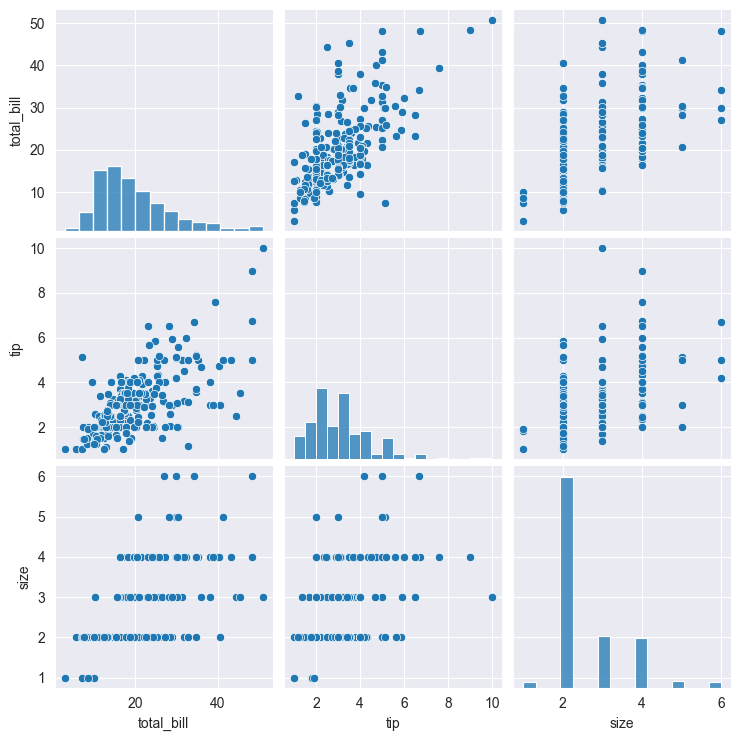

In [34]:
# Using pairplot to plot the pairwise relationship btw each numerical columns present in the dataframe
sns.pairplot(tips_data)

*Eslatma: Juftlik diagrammasi funksiyasi shunday o‘qlar panjarasini yaratadiki, unda ma’lumotlardagi har bir o‘zgaruvchi bitta qator bo‘ylab y o‘qida va bitta ustun bo‘ylab x o‘qida joylashtiriladi.*

Qidiruv ma’lumotlarini tahlil qilishning asosiy tarkibiy qismlariga quyidagilar kiradi:

* ’Ma’lumotlarni umumlashtirish’: Ma’lumotlarning markaziy tendensiya, o‘zgaruvchanlik va taqsimot kabi asosiy xususiyatlarini tavsiflash.

* ’Ma’lumotlarni vizuallashtirish’: Ma’lumotlar tuzilishini yaxshiroq tushunish va qonuniyatlar yoki tendensiyalarni aniqlash uchun ularning ko‘rgazmali tasvirlarini yaratish.

* ’Ma’lumotlarni tozalash’: Tahlil aniqligini ta’minlash maqsadida yetishmayotgan yoki nomuvofiq ma’lumotlarni aniqlash va ular bilan ishlash.

* ’Statistik tahlil’: O‘zgaruvchilar o‘rtasidagi munosabatlarni o‘rganish va farazlarni tekshirish uchun statistik usullardan foydalanish.

* ’Qonuniyatlarni aniqlash’: Ma’lumotlardagi chetki qiymatlar, klasterlar yoki boshqa g‘ayrioddiy naqshlarni topish.

* ’Faraz yaratish’: Kuzatilgan qonuniyatlar asosida ma’lumotlar haqida dastlabki farazlar yoki savollarni shakllantirish.


*Eslatma: Ushbu misolda "ma’lumotlar" deb nomlangan ma’lumotlar to‘plami ChatGPT tomonidan faqat vizualizatsiyani namoyish etish maqsadida yaratilgan sun’iy o‘quv ma’lumotlar to‘plamidir. Shu sababli, har bir grafikdan olingan xulosalar haqida fikr bildirmayman.